# Ventilator Pressure Prediction — Assignment #1

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
N_FOLDS = 5
N_STEPS = 80
DATA = "/kaggle/input/competitions/ventilator-pressure-prediction"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

In [11]:
DTYPES = {
    "id": "int32",
    "breath_id": "int32",
    "R": "int8",
    "C": "int8",
    "time_step": "float32",
    "u_in": "float32",
    "u_out": "int8",
    "pressure": "float32",
}

train = pd.read_csv(f"{DATA}/train.csv", dtype=DTYPES)
test = pd.read_csv(f"{DATA}/test.csv", dtype={k: v for k, v in DTYPES.items() if k != "pressure"})
sample_sub = pd.read_csv(f"{DATA}/sample_submission.csv")

for df in (train, test):
    df["t"] = df.groupby("breath_id").cumcount().astype("int16")
    df["switch_t"] = df.breath_id.map(df[df.u_out == 1].groupby("breath_id").t.min()).fillna(N_STEPS)

print("train", train.shape, "test", test.shape)
train.head()

train (6036000, 10) test (4024000, 9)


,id,breath_id,R,C,time_step,u_in,u_out,pressure,t,switch_t
0,1,1,20,50,0.000000,0.083334,0,5.837492,0,30
1,2,1,20,50,0.033652,18.383041,0,5.907794,1,30
2,3,1,20,50,0.067514,22.509277,0,7.876254,2,30
3,4,1,20,50,0.101542,22.808823,0,11.742872,3,30
4,5,1,20,50,0.135756,25.355850,0,12.234987,4,30


## EDA

## What the columns mean (explanation made with chatik gpt)

The data comes from a **simulated ventilator** connected to an **artificial lung**. The ventilator
pushes air in through an inlet valve, then lets it out through an exhaust valve. One *breath* is
one full push-and-release cycle, recorded as 80 consecutive rows.

| Column | Meaning |
|---|---|
| `id` | Row identifier. Nothing to learn from it. |
| `breath_id` | Which breath this row belongs to. 80 rows share each value — this is the real unit of observation. |
| `R` | Airway **resistance** (5, 20, 50). How narrow the tube is — how hard it is to push air through. Constant within a breath. |
| `C` | Lung **compliance** (10, 20, 50). How stretchy the lung is — how easily it expands. Constant within a breath. |
| `time_step` | Seconds since the breath started (0 → ~3 s, roughly every 0.03 s). |
| `u_in` | Control input for the **inlet** valve, 0–100. How far open it is: 0 = shut, 100 = fully open. |
| `u_out` | Control input for the **exhaust** valve, 0 or 1. `0` = inhaling (air going in), `1` = exhaling. |
| `pressure` | **Target.** Airway pressure in cmH₂O at this timestep. |

**The task:** given the valve controls (`u_in`, `u_out`) and the lung being ventilated (`R`, `C`),
predict the resulting `pressure` at every timestep.

Intuition: `R` and `C` are the *lung*, `u_in`/`u_out` are the *controls*, and `pressure` is what
the two produce together. Only the `u_out == 0` part is scored — that's the phase the ventilator
actually steers.

In [12]:
print("missing values:", train.isna().sum().sum(), test.isna().sum().sum())
print("breaths in train:", train.breath_id.nunique(), " in test:", test.breath_id.nunique())
print("breath_ids in both:", len(np.intersect1d(train.breath_id.unique(), test.breath_id.unique())))

rows_per_breath = train.groupby("breath_id").size()
print("rows per breath:", rows_per_breath.min(), "to", rows_per_breath.max())

missing values: 0 0
breaths in train: 75450  in test: 50300
breath_ids in both: 0
rows per breath: 80 to 80


**Conclusion:** data is a grouped fixed length time series. This means that we need to ensure the train-val split will not mix the breath_id's, otherwise we will have serious data leakage. (because the data is very similar in close time steps).

In [13]:
print("R values:", sorted(train.R.unique()), "   C values:", sorted(train.C.unique()))

rc_tr = train.groupby("breath_id")[["R", "C"]].first().value_counts(normalize=True).rename("train %")
rc_te = test.groupby("breath_id")[["R", "C"]].first().value_counts(normalize=True).rename("test %")
(pd.concat([rc_tr, rc_te], axis=1) * 100).round(2).sort_index()

R values: [np.int8(5), np.int8(20), np.int8(50)]    C values: [np.int8(10), np.int8(20), np.int8(50)]


train %  test %
R  C                  
5  10    11.02   10.81
   20    10.97   10.84
   50    10.96   10.83
20 10     8.05    8.53
   20     8.23    8.13
   50    10.85   10.93
50 10    18.13   18.05
   20    10.95   10.94
   50    10.85   10.94

**Conclusion:** data proportions match in train and test dataset. Therefore, we can likely use a random split for train/val. Also, probably need to make R and C categorical features and use an embedding, since for now no evidence that the numbers values influence something. 

min -1.8957, max 64.8210, mean 11.220, std 8.110
distinct pressure values: 950
gap between them: min 0.070297, median 0.070302, max 0.070305


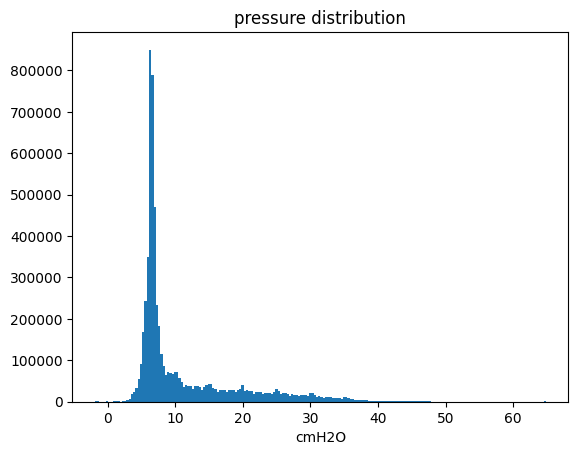

In [14]:
p = train.pressure.values
pressure_grid = np.unique(p)
gaps = np.diff(pressure_grid)

print(f"min {p.min():.4f}, max {p.max():.4f}, mean {p.mean():.3f}, std {p.std():.3f}")
print("distinct pressure values:", len(pressure_grid))
print(f"gap between them: min {gaps.min():.6f}, median {np.median(gaps):.6f}, max {gaps.max():.6f}")

plt.hist(p, bins=200)
plt.title("pressure distribution")
plt.xlabel("cmH2O")
plt.show()

**Conclusion:** the target is not continuous, since there are only 950 distinct values for 6m rows. Also, the pressure values have a difference of around 0.07(with rounding error), so we can look at the values as a grid.

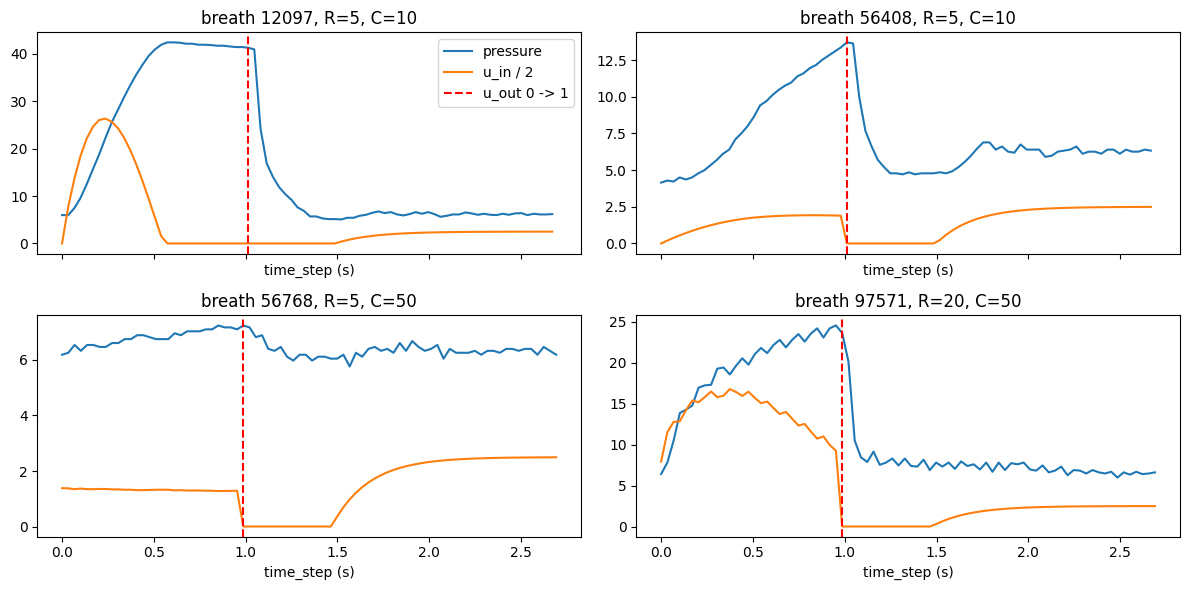

In [15]:
ids = train.breath_id.drop_duplicates().sample(4, random_state=SEED).values
sel = train[train.breath_id.isin(ids)]

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for (bid, b), ax in zip(sel.groupby("breath_id"), axes.ravel()):
    ax.plot(b.time_step, b.pressure, label="pressure")
    ax.plot(b.time_step, b.u_in / 2, label="u_in / 2")
    ax.axvline(b.loc[b.u_out == 1, "time_step"].min(), color="red", ls="--", label="u_out 0 -> 1")
    ax.set_title(f"breath {bid}, R={b.R.iloc[0]}, C={b.C.iloc[0]}")
    ax.set_xlabel("time_step (s)")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

**Conclusion:** pressure does not follow u_in, it builds up while the inlet valve is open and then drops on its own after u_out flips to 1. So the features that matter are cumulative ones, the running sum and the integral of u_in, and not u_in at the current step. Also the two phases are clearly different, the inspiratory part is driven and the rest is just decay, which is why only u_out == 0 is scored.

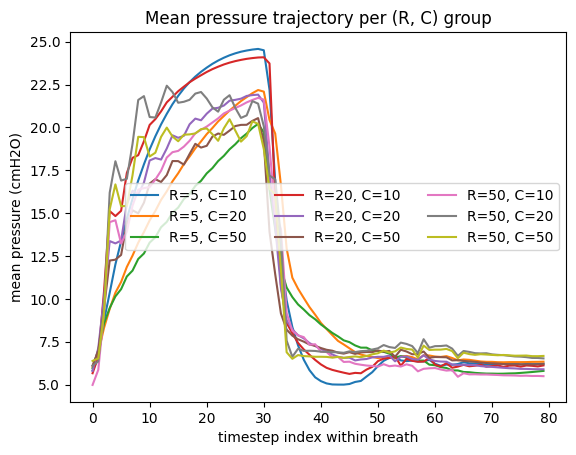

In [16]:
mean_curve = train.groupby(["R", "C", "t"]).pressure.mean().reset_index()

for (r, c), grp in mean_curve.groupby(["R", "C"]):
    plt.plot(grp.t, grp.pressure, label=f"R={r}, C={c}")
plt.xlabel("timestep index within breath")
plt.ylabel("mean pressure (cmH2O)")
plt.title("Mean pressure trajectory per (R, C) group")
plt.legend(ncol=3)
plt.show()

**Conclusion**: the groups of R, C have different trajectories. 

scored rows (u_out == 0): train 0.380, test 0.380

seconds between samples inside a breath:
count    5.960550e+06
mean     3.310000e-02
std      1.700000e-03
min      3.140000e-02
25%      3.190000e-02
50%      3.350000e-02
75%      3.400000e-02
max      2.511000e-01


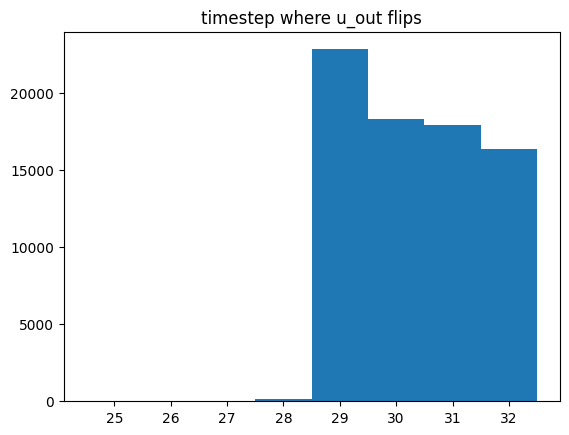

In [17]:
switch = train.groupby("breath_id").switch_t.first()
dt = train.groupby("breath_id").time_step.diff().dropna()

print(f"scored rows (u_out == 0): train {(train.u_out == 0).mean():.3f}, test {(test.u_out == 0).mean():.3f}")
print("\nseconds between samples inside a breath:")
print(dt.describe().round(4).to_string())

plt.hist(switch, bins=np.arange(switch.min(), switch.max() + 2) - 0.5)
plt.title("timestep where u_out flips")
plt.show()

**Conclusion:** Only 38% of rows are graded(u_out = 0). The train loss should not be weighted towards the u_out = 1(since not graded), but not removed, since u_out = 1 are still valid inputs. 

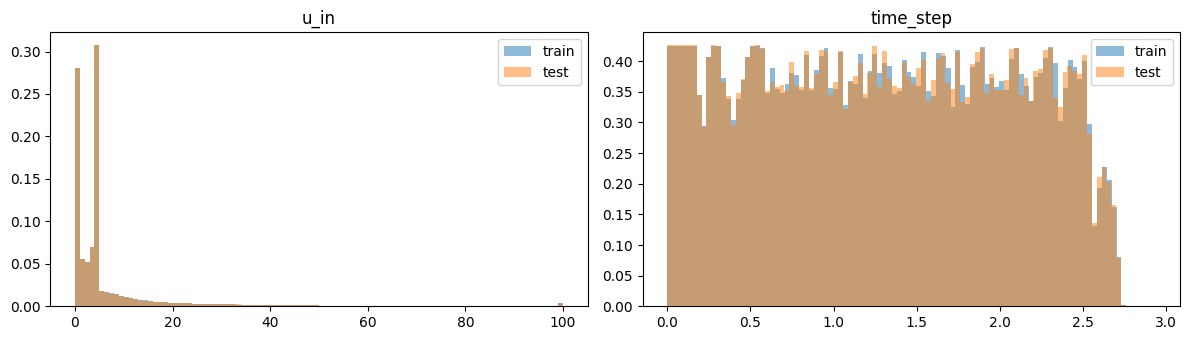

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for col, ax in zip(["u_in", "time_step"], axes):
    ax.hist(train[col], bins=100, density=True, alpha=0.5, label="train")
    ax.hist(test[col], bins=100, density=True, alpha=0.5, label="test")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

**Conclusion:** train and test look like the same distribution, so a random split should be fine. Checked properly with adversarial validation below.

## METRIC

In [19]:
def competition_mae(y_true, y_pred, u_out):
    mask = u_out == 0
    return np.abs(y_true[mask] - y_pred[mask]).mean()


y = train.pressure.values
uo = train.u_out.values

const = y[uo == 0].mean()
print(f"constant prediction ({const:.2f} cmH2O): MAE {competition_mae(y, np.full_like(y, const), uo):.4f}")

lut = (train[train.u_out == 0]
       .groupby(["R", "C", "t"], as_index=False).pressure.mean()
       .rename(columns={"pressure": "p_lut"}))
pred_lut = train[["R", "C", "t"]].merge(lut, on=["R", "C", "t"], how="left").p_lut.fillna(const).values
print(f"per-(R, C, timestep) lookup table: MAE {competition_mae(y, pred_lut, uo):.4f}")

constant prediction (17.60 cmH2O): MAE 7.6192
per-(R, C, timestep) lookup table: MAE 6.1648


**Thoughts about the metric:** 
1. MAE is bad for backpropagation in the sense that the gradient does not see the scale of the error, meaning the gradient will always be +-1. So it poorly handles close estimations.
2. The good thing is that it is not affected by outliers as much as MSE.
3. Maybe add other metrics like MSE to see if outliers are badly predicted.

**Complementary metrics:** RMSE, MAE per (R, C) group, MAE per timestep, share of rows within 0.5 cmH2O. All computed in the LightGBM section.

**Alternative target metric:** MAE averaged per breath first, plus a penalty on the worst error inside that breath. For a ventilator a model that is right on average but spikes once is more dangerous than one that is a bit off everywhere, and a row level mean cannot say that. Averaging per breath first also stops the bigger (R, C) groups from dominating the score.

## VALIDATION

Validation strategy: 5-fold KFold over the unique breath_ids (the same as GroupKFold with breath_id as the group), so a breath is never split between train and val.

In [20]:
breath_ids = np.sort(train.breath_id.unique())
fold_of = pd.Series(-1, index=breath_ids, dtype="int8")
for f, (_, va) in enumerate(KFold(N_FOLDS, shuffle=True, random_state=SEED).split(breath_ids)):
    fold_of.iloc[va] = f

train["fold"] = train.breath_id.map(fold_of)
print(train.fold.value_counts().sort_index().to_string())

# share (%) of each fold taken by each (R, C) cell
(pd.crosstab([train.R, train.C], train.fold, normalize="columns") * 100).round(2)

fold
0    1207200
1    1207200
2    1207200
3    1207200
4    1207200


fold       0      1      2      3      4
R  C                                    
5  10  10.83  11.06  11.07  11.01  11.11
   20  11.23  10.77  10.93  10.76  11.16
   50  11.20  10.69  10.62  11.34  10.97
20 10   8.06   8.16   8.01   8.10   7.89
   20   8.14   8.42   8.50   8.10   7.98
   50  10.64  11.16  10.78  10.68  10.98
50 10  17.66  18.02  18.40  18.24  18.32
   20  11.31  10.98  10.83  11.05  10.56
   50  10.91  10.74  10.86  10.72  11.04

**Conclusion:** the shares are basically the same in every fold, biggest difference is under 1 pp. So no need to stratify, plain KFold on breath_id is enough. The cells are not uniform though, (50, 10) is 18% and (20, 10) is 8%, but that is the same in train and test so it does not break anything.

In [21]:
def breath_features(df):
    return df.groupby("breath_id").agg(
        R=("R", "first"), C=("C", "first"),
        u_in_mean=("u_in", "mean"), u_in_std=("u_in", "std"),
        u_in_max=("u_in", "max"), u_in_first=("u_in", "first"),
        u_in_sum=("u_in", "sum"), t_max=("time_step", "max"),
        switch_t=("switch_t", "first"),
    )


adv = pd.concat([breath_features(train).assign(is_test=0),
                 breath_features(test).assign(is_test=1)], ignore_index=True)

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED))
auc = cross_val_score(clf, adv.drop(columns="is_test").fillna(0), adv.is_test,
                      cv=5, scoring="roc_auc", n_jobs=-1)
print(f"adversarial ROC-AUC = {auc.mean():.4f} +/- {auc.std():.4f} (0.5 = indistinguishable)")

adversarial ROC-AUC = 0.4953 +/- 0.0023 (0.5 = indistinguishable)


**Conclusion:** AUC 0.4953, so logistic regression cannot tell a train breath from a test breath. The split is random, there is no shift to handle, and my CV should track the leaderboard.

## LIGHTGBM BASELINE

### Feature list

In [22]:
def add_features(df):
    df = df.sort_values(["breath_id", "t"]).reset_index(drop=True)
    g = df.groupby("breath_id")

    df["dt"] = g.time_step.diff().fillna(0)

    for k in (1, 2, 3, 4):
        df[f"u_in_lag{k}"] = g.u_in.shift(k)
        df[f"u_in_lead{k}"] = g.u_in.shift(-k)
    df["u_in_diff_back"] = df.u_in - df.u_in_lag1
    df["u_in_diff_back2"] = df.u_in - df.u_in_lag2
    df["u_in_diff_fwd"] = df.u_in_lead1 - df.u_in
    df["u_in_accel"] = df.u_in_diff_fwd - df.u_in_diff_back

    df["u_in_cumsum"] = g.u_in.cumsum()
    df["u_in_cummean"] = df.u_in_cumsum / (df.t + 1)
    df["u_in_cummax"] = g.u_in.cummax()
    df["v_est"] = (df.u_in * df.dt).groupby(df.breath_id).cumsum()

    g = df.groupby("breath_id")
    for span in (4, 12, 30):
        df[f"u_in_ewm{span}"] = g.u_in.ewm(span=span).mean().to_numpy()
    for win in (3, 9):
        df[f"u_in_roll{win}"] = g.u_in.rolling(win, min_periods=1).mean().to_numpy()
    df["u_in_rollstd9"] = g.u_in.rolling(9, min_periods=1).std().to_numpy()
    df["u_in_rollmax9"] = g.u_in.rolling(9, min_periods=1).max().to_numpy()
    df["u_in_rollmin9"] = g.u_in.rolling(9, min_periods=1).min().to_numpy()

    df["tau"] = df.R.astype("float32") * df.C
    df["p_resist"] = df.u_in * df.R
    df["p_elastic"] = df.v_est / df.C
    df["p_phys"] = df.p_resist + df.p_elastic

    g = df.groupby("breath_id")
    for stat in ("mean", "std", "max", "sum", "first"):
        df[f"u_in_breath_{stat}"] = g.u_in.transform(stat)
    df["v_total"] = g.v_est.transform("max")
    df["u_in_vs_mean"] = df.u_in - df.u_in_breath_mean
    df["u_in_share"] = df.u_in / (df.u_in_breath_sum + 1e-6)
    df["u_in_future_sum"] = df.u_in_breath_sum - df.u_in_cumsum
    df["v_frac"] = df.v_est / (df.v_total + 1e-6)

    df["t_to_switch"] = df.switch_t - df.t
    df["t_frac"] = df.t / df.switch_t

    df["R_cat"] = df.R.map({5: 0, 20: 1, 50: 2}).astype("int8")
    df["C_cat"] = df.C.map({10: 0, 20: 1, 50: 2}).astype("int8")
    df["RC_cat"] = df.R_cat * 3 + df.C_cat

    floats = df.select_dtypes("float64").columns
    df[floats] = df[floats].astype("float32")
    return df


train = add_features(train)
test = add_features(test)

y = train.pressure.values
uo = train.u_out.values

DROP = {"id", "breath_id", "pressure", "u_out", "fold", "R", "C"}
FEATURES = [c for c in train.columns if c not in DROP]
CATS = ["R_cat", "C_cat", "RC_cat"]

FEATURE_GROUPS = {
    "raw": ["u_in", "t", "time_step", "dt"],
    "lag/lead": [f"u_in_lag{k}" for k in (1, 2, 3, 4)] + [f"u_in_lead{k}" for k in (1, 2, 3, 4)]
                + ["u_in_diff_back", "u_in_diff_back2", "u_in_diff_fwd", "u_in_accel"],
    "cumulative": ["u_in_cumsum", "u_in_cummean", "u_in_cummax", "v_est", "u_in_future_sum"],
    "smoothed": ["u_in_ewm4", "u_in_ewm12", "u_in_ewm30", "u_in_roll3", "u_in_roll9",
                 "u_in_rollstd9", "u_in_rollmax9", "u_in_rollmin9"],
    "physics": ["p_resist", "p_elastic", "p_phys", "tau"],
    "breath level": ["u_in_breath_mean", "u_in_breath_std", "u_in_breath_max", "u_in_breath_sum",
                     "u_in_breath_first", "v_total", "u_in_vs_mean", "u_in_share", "v_frac",
                     "switch_t", "t_to_switch", "t_frac"],
    "categorical": CATS,
}

print(len(FEATURES), "features")

48 features


| Group | Feature | Why |
|---|---|---|
| raw | `u_in` | inlet valve opening, the raw control signal |
| | `time_step` | seconds since the breath started |
| | `t` | position in the breath (0–79), every breath has 80 rows so this is a clean index |
| | `dt` | gap to the previous sample, the spacing is not perfectly uniform |
| lag/lead | `u_in_lag1` … `u_in_lag4` | `u_in` 1–4 steps ago, pressure reacts with a delay (4 is where the lag plot still shows signal) |
| | `u_in_lead1` … `u_in_lead4` | `u_in` 1–4 steps ahead, allowed because the whole breath is given at test time |
| | `u_in_diff_back`, `u_in_diff_back2` | is the valve opening or closing right now (over 1 and 2 steps) |
| | `u_in_diff_fwd` | is the valve about to open or close |
| | `u_in_accel` | second difference, how sharply the valve is changing |
| cumulative | `u_in_cumsum` | total `u_in` so far, pressure is an integral of `u_in`, not `u_in` itself |
| | `u_in_cummean` | average `u_in` so far, the cumsum without the growth with `t` |
| | `u_in_cummax` | strongest push so far in the breath |
| | `v_est` | integral of `u_in` over the real `dt`, the volume already delivered |
| | `u_in_future_sum` | `u_in` still to come in the breath |
| smoothed | `u_in_ewm4`, `u_in_ewm12`, `u_in_ewm30` | leaky integrals of `u_in` with short / medium / long memory, pressure behaves like `u_in` convolved with exp(-t/RC) |
| | `u_in_roll3`, `u_in_roll9` | local averages, remove the jumpiness of `u_in` |
| | `u_in_rollstd9`, `u_in_rollmax9`, `u_in_rollmin9` | how unstable `u_in` has been lately, its recent peak and floor |
| physics | `p_resist` | R·u_in, the resistive part of P = R·Q + V/C |
| | `p_elastic` | v_est / C, the elastic part of the same equation |
| | `p_phys` | the two parts added, a zero-parameter estimate of the target |
| | `tau` | R·C, the time constant that sets the shape of the curve |
| breath level | `u_in_breath_mean/std/max/sum/first` | summary of the push over the whole breath (constant within a breath), higher sum means higher pressure |
| | `v_total` | total volume delivered over the whole breath |
| | `u_in_vs_mean` | this `u_in` against the breath average |
| | `u_in_share` | this `u_in` as a share of the breath total |
| | `v_frac` | fraction of the breath volume delivered so far |
| | `switch_t` | timestep where `u_out` flips, varies between 25 and 32 |
| | `t_to_switch` | steps left until exhale starts |
| | `t_frac` | position inside the inspiratory phase, 0 at the start and 1 at the switch |
| categorical | `R_cat`, `C_cat` | R and C as codes (3 levels each), not magnitudes |
| | `RC_cat` | the 9 lung configurations as one category |

### Where the features come from

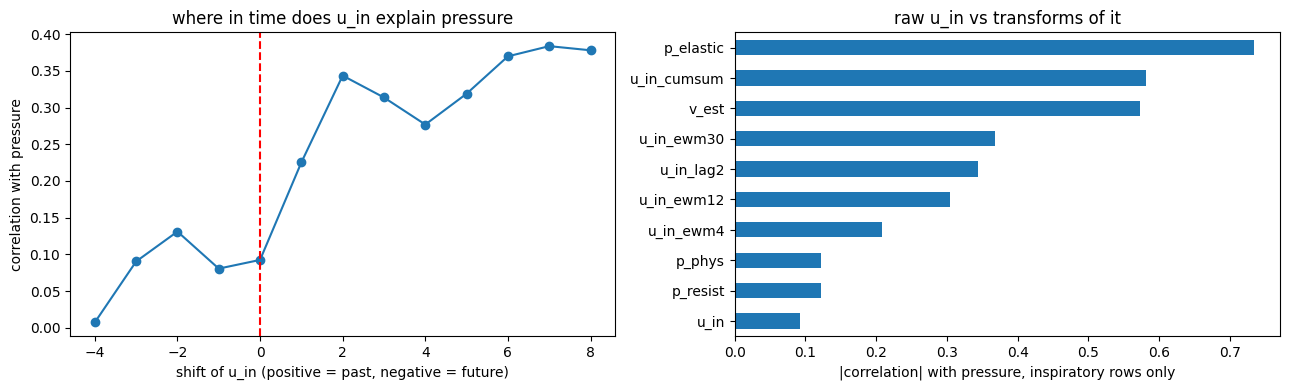

p_elastic      0.734
u_in_cumsum    0.582
v_est          0.572
u_in_ewm30     0.368
u_in_lag2      0.344
u_in_ewm12     0.305
u_in_ewm4      0.209
p_phys         0.123
p_resist       0.122
u_in           0.092


In [23]:
EDA_BREATHS = 3000

samp = train[train.breath_id.isin(np.random.choice(train.breath_id.unique(), EDA_BREATHS, replace=False))]
ins = samp.u_out == 0
press = samp.pressure[ins]

lags = range(-4, 9)
lag_corr = [samp.groupby("breath_id").u_in.shift(k)[ins].corr(press) for k in lags]

candidates = ["u_in", "u_in_lag2", "u_in_cumsum", "v_est", "u_in_ewm4", "u_in_ewm12", "u_in_ewm30",
              "p_resist", "p_elastic", "p_phys"]
corrs = samp.loc[ins, candidates].corrwith(press).abs().sort_values()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(lags, lag_corr, marker="o")
ax[0].axvline(0, color="red", ls="--")
ax[0].set_xlabel("shift of u_in (positive = past, negative = future)")
ax[0].set_ylabel("correlation with pressure")
ax[0].set_title("where in time does u_in explain pressure")
corrs.plot.barh(ax=ax[1])
ax[1].set_xlabel("|correlation| with pressure, inspiratory rows only")
ax[1].set_title("raw u_in vs transforms of it")
plt.tight_layout()
plt.show()

print(corrs[::-1].round(3).to_string())

**Conclusion:** the left plot says how far back and forward `u_in` still explains pressure, which sets the lag window. The right plot says raw `u_in` is the weakest thing I could feed the model, and that cumulative and physics transforms of it are much stronger.

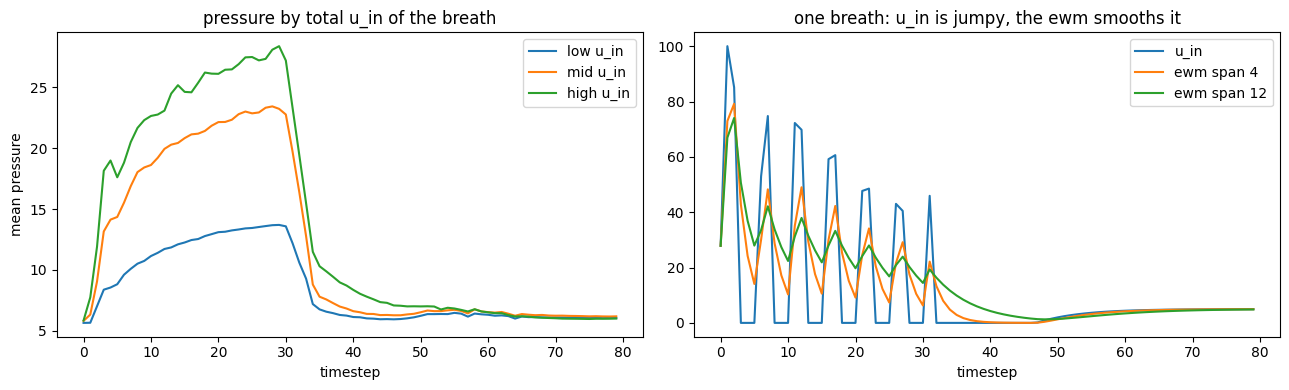

In [24]:
tercile = pd.qcut(samp.u_in_breath_sum, 3, labels=["low u_in", "mid u_in", "high u_in"])
one = samp[samp.breath_id == samp.breath_id.iloc[0]]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name in tercile.cat.categories:
    ax[0].plot(samp[tercile == name].groupby("t").pressure.mean(), label=name)
ax[0].set_xlabel("timestep")
ax[0].set_ylabel("mean pressure")
ax[0].set_title("pressure by total u_in of the breath")
ax[0].legend()

ax[1].plot(one.t, one.u_in, label="u_in")
ax[1].plot(one.t, one.u_in_ewm4, label="ewm span 4")
ax[1].plot(one.t, one.u_in_ewm12, label="ewm span 12")
ax[1].set_xlabel("timestep")
ax[1].set_title("one breath: u_in is jumpy, the ewm smooths it")
ax[1].legend()
plt.tight_layout()
plt.show()

**Conclusion:** breaths with more total `u_in` reach higher pressure, so breath level sums are worth putting on every row. And `u_in` jumps around a lot while the ewm of it is smooth, which is closer to how pressure actually moves.

### Tuning log

In [25]:
BASE = dict(metric="mae", learning_rate=0.2, num_leaves=96, min_data_in_leaf=64,
            feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1,
            lambda_l2=1.0, verbosity=-1, seed=SEED)


def fit_lgb(params, fit_rows, val_rows, feats=FEATURES, rounds=3000):
    cats = [c for c in CATS if c in feats]
    dtrain = lgb.Dataset(train.loc[fit_rows, feats], y[fit_rows], categorical_feature=cats)
    dvalid = lgb.Dataset(train.loc[val_rows, feats], y[val_rows], categorical_feature=cats)
    return lgb.train(params, dtrain, num_boost_round=rounds, valid_sets=[dvalid],
                     callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(250)])


fit0 = (uo == 0) & (train.fold != 0).values
val0 = (uo == 0) & (train.fold == 0).values

TRIALS = {
    "L1, leaves=96": dict(objective="regression_l1"),
    "Huber, leaves=96": dict(objective="huber", alpha=1.0),
    "L2, leaves=96": dict(objective="regression")
}
for name, override in TRIALS.items():
    print(f"training {name}", flush=True)
    m = fit_lgb({**BASE, **override}, fit0, val0)
    print(f"{name}: MAE {m.best_score['valid_0']['l1']:.4f} at {m.best_iteration} trees\n", flush=True)

training L1, leaves=96
[250]	valid_0's l1: 0.736424
[500]	valid_0's l1: 0.665547
[750]	valid_0's l1: 0.632095
[1000]	valid_0's l1: 0.610539
[1250]	valid_0's l1: 0.595233
[1500]	valid_0's l1: 0.584006
[1750]	valid_0's l1: 0.576338
[2000]	valid_0's l1: 0.569645
[2250]	valid_0's l1: 0.564562
[2500]	valid_0's l1: 0.559895
[2750]	valid_0's l1: 0.555848
[3000]	valid_0's l1: 0.552104
L1, leaves=96: MAE 0.5521 at 3000 trees

training Huber, leaves=96
[250]	valid_0's l1: 0.740833
[500]	valid_0's l1: 0.629837
[750]	valid_0's l1: 0.586746
[1000]	valid_0's l1: 0.561315
[1250]	valid_0's l1: 0.545652
[1500]	valid_0's l1: 0.533435
[1750]	valid_0's l1: 0.524121
[2000]	valid_0's l1: 0.516825
[2250]	valid_0's l1: 0.511346
[2500]	valid_0's l1: 0.506433
[2750]	valid_0's l1: 0.502422
[3000]	valid_0's l1: 0.498723
Huber, leaves=96: MAE 0.4987 at 3000 trees

training L2, leaves=96
[250]	valid_0's l1: 0.699685
[500]	valid_0's l1: 0.634782
[750]	valid_0's l1: 0.603349
[1000]	valid_0's l1: 0.583448
[1250]	valid

**Conclusion:** Huber won with 0.4987, then L2 0.5288, then L1 0.5521. But none of them converged, all three were still going down at 3000 trees, so this really compares how fast each objective learns and not which one is best. Huber winning makes sense: L1 has a constant +-1 gradient so it barely slows down near the answer, Huber is quadratic there. I take Huber for the full run.

### Full 5-fold run

In [26]:
BEST = {**BASE, "objective": "huber",  "alpha": 1.0, "num_leaves": 96}

test_scored = (test.u_out == 0).values
oof = np.zeros(len(train), dtype="float32")
test_pred = np.zeros(len(test), dtype="float32")
fold_scores, models = [], []

for f in range(N_FOLDS):
    fit_rows = (uo == 0) & (train.fold != f).values
    val_rows = (uo == 0) & (train.fold == f).values

    print(f"fold {f}: training", flush=True)
    model = fit_lgb(BEST, fit_rows, val_rows)

    print(f"fold {f}: predicting", flush=True)
    oof[val_rows] = model.predict(train.loc[val_rows, FEATURES])
    test_pred[test_scored] += model.predict(test.loc[test_scored, FEATURES]) / N_FOLDS

    fold_scores.append(np.abs(y[val_rows] - oof[val_rows]).mean())
    models.append(model)
    print(f"fold {f}: MAE {fold_scores[-1]:.4f}\n", flush=True)

lgb_mae = competition_mae(y, oof, uo)
fold_std = np.std(fold_scores)
print(f"LightGBM OOF MAE: {lgb_mae:.4f}, std across folds: {fold_std:.5f}")

fold 0: training
[250]	valid_0's l1: 0.618928
[500]	valid_0's l1: 0.54335
[750]	valid_0's l1: 0.515987
[1000]	valid_0's l1: 0.500414
[1250]	valid_0's l1: 0.491474
[1500]	valid_0's l1: 0.485302
[1750]	valid_0's l1: 0.480933
[2000]	valid_0's l1: 0.477314
[2250]	valid_0's l1: 0.474479
[2500]	valid_0's l1: 0.472084
[2750]	valid_0's l1: 0.4701
[3000]	valid_0's l1: 0.468429
fold 0: predicting
fold 0: MAE 0.4684

fold 1: training
[250]	valid_0's l1: 0.622222
[500]	valid_0's l1: 0.547584
[750]	valid_0's l1: 0.519022
[1000]	valid_0's l1: 0.504801
[1250]	valid_0's l1: 0.495221
[1500]	valid_0's l1: 0.48879
[1750]	valid_0's l1: 0.48411
[2000]	valid_0's l1: 0.480365
[2250]	valid_0's l1: 0.477317
[2500]	valid_0's l1: 0.475205
[2750]	valid_0's l1: 0.473736
[3000]	valid_0's l1: 0.472309
fold 1: predicting
fold 1: MAE 0.4723

fold 2: training
[250]	valid_0's l1: 0.630684
[500]	valid_0's l1: 0.552002
[750]	valid_0's l1: 0.523137
[1000]	valid_0's l1: 0.508667
[1250]	valid_0's l1: 0.498588
[1500]	valid_0'

### Feature importance

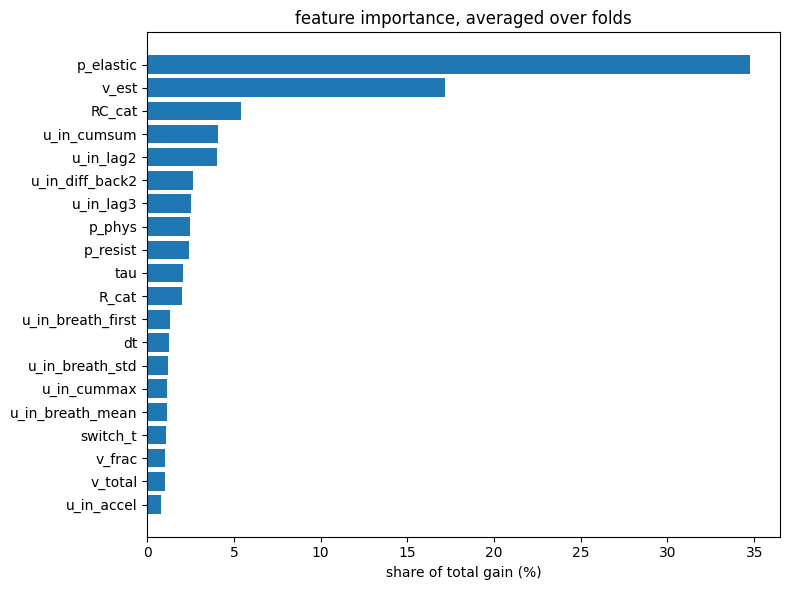

In [27]:
imp = pd.DataFrame({
    "feature": FEATURES,
    "gain": np.mean([m.feature_importance("gain") for m in models], axis=0),
}).sort_values("gain", ascending=False)
imp["gain_pct"] = imp.gain / imp.gain.sum() * 100

top = imp.head(20).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top.feature, top.gain_pct)
plt.xlabel("share of total gain (%)")
plt.title("feature importance, averaged over folds")
plt.tight_layout()
plt.show()

**Conclusion:** yes. p_elastic is the single best feature and the whole physics group is 41.7% of the gain with only 4 features. v_est and u_in_cumsum are right behind it, so the model mostly runs on "how much air has already gone in", which is what the EDA said it would.

### Importance by feature group

In [28]:
imp["group"] = imp.feature.map({c: grp for grp, cols in FEATURE_GROUPS.items() for c in cols})

by_group = imp.groupby("group").agg(
    features=("feature", "size"),
    gain_pct=("gain_pct", "sum"),
    best_feature=("feature", "first"),
).sort_values("gain_pct", ascending=False)

print(by_group.round(2).to_string())
print("\nlowest gain features, candidates to drop:")
print(imp.tail(8)[["feature", "group", "gain_pct"]].round(2).to_string(index=False))

              features  gain_pct       best_feature
group                                              
physics              4     41.70          p_elastic
cumulative           5     23.31              v_est
lag/lead            12     13.11          u_in_lag2
breath level        12      9.40  u_in_breath_first
categorical          3      7.86             RC_cat
smoothed             8      2.71         u_in_ewm12
raw                  4      1.90                 dt

lowest gain features, candidates to drop:
      feature        group  gain_pct
   u_in_roll9     smoothed      0.21
u_in_rollmax9     smoothed      0.19
   u_in_lead4     lag/lead      0.18
   u_in_lead1     lag/lead      0.14
  t_to_switch breath level      0.14
   u_in_lead3     lag/lead      0.13
         u_in          raw      0.11
            t          raw      0.10


**Conclusion:** physics carries by far the most gain per feature (4 features, 41.7%). smoothed is the opposite, 8 features for 2.7% together. The dead weight is at the bottom of the list: u_in_roll9, u_in_rollmax9 and the leads u_in_lead1/3/4.

### Does each group actually earn its place

Importance only says what the model used, not what it needed — two correlated features split the
credit between them and both look weak. So retrain fold 0 with each group removed and measure the
damage. A positive delta means dropping the group hurt, so the group was pulling its weight.

Shorter and shallower than the real run, because only the differences matter here.

In [29]:
ABL_PARAMS = {**BASE, "objective": "regression_l1", "num_leaves": 128, "learning_rate": 0.15}
ABL_ROUNDS = 800


def fold0_mae(feats):
    cats = [c for c in CATS if c in feats]
    d_fit = lgb.Dataset(train.loc[fit0, feats], y[fit0], categorical_feature=cats)
    d_val = lgb.Dataset(train.loc[val0, feats], y[val0], categorical_feature=cats)
    m = lgb.train(ABL_PARAMS, d_fit, num_boost_round=ABL_ROUNDS, valid_sets=[d_val],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    return m.best_score["valid_0"]["l1"]


base = fold0_mae(FEATURES)
rows = [{"dropped": "nothing", "n_features": len(FEATURES), "MAE": base, "delta": 0.0}]
for name, cols in FEATURE_GROUPS.items():
    keep = [c for c in FEATURES if c not in cols]
    mae = fold0_mae(keep)
    rows.append({"dropped": name, "n_features": len(keep), "MAE": mae, "delta": mae - base})

pd.DataFrame(rows).sort_values("delta", ascending=False).round(4)

,dropped,n_features,MAE,delta
2,lag/lead,36,0.6764,0.0748
6,breath level,36,0.6605,0.0589
7,categorical,45,0.6309,0.0293
5,physics,44,0.6149,0.0132
3,cumulative,43,0.6128,0.0112
4,smoothed,40,0.6076,0.0059
1,raw,44,0.6050,0.0033
0,nothing,48,0.6016,0.0000


**Conclusion:** every group helps, all deltas are positive, so I do not drop anything. But the order is not the same as the importance: lag/lead is the most needed (+0.0748) even though it is only 13% of the gain, and physics is only +0.0132 even though it is 41.7% of the gain.

The reason is that p_elastic = v_est / C, so if I drop physics the cumulative group still carries almost the same information and the model barely notices. lag/lead is the only place the local shape of u_in comes from, nothing else covers it. So importance shows what the model used, the ablation shows what it actually needed, and here they disagree.

### Complementary metrics

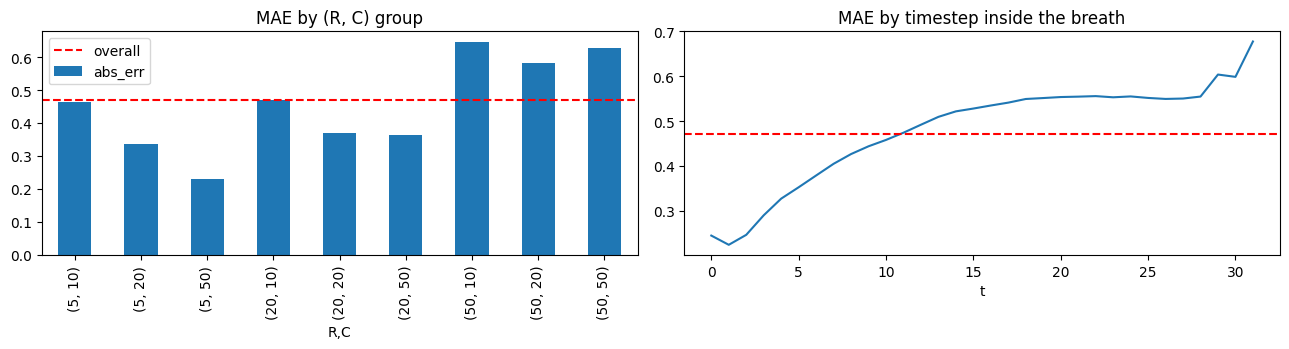

RMSE: 0.7674
within 0.5 cmH2O: 69.9%


In [30]:
scored = uo == 0
err = pd.DataFrame({"R": train.R, "C": train.C, "t": train.t, "abs_err": np.abs(y - oof)})[scored]

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
err.groupby(["R", "C"]).abs_err.mean().plot.bar(ax=ax[0])
ax[0].axhline(lgb_mae, color="red", ls="--", label="overall")
ax[0].set_title("MAE by (R, C) group")
ax[0].legend()
err.groupby("t").abs_err.mean().plot(ax=ax[1])
ax[1].axhline(lgb_mae, color="red", ls="--")
ax[1].set_title("MAE by timestep inside the breath")
plt.tight_layout()
plt.show()

print(f"RMSE: {np.sqrt(np.mean((y[scored] - oof[scored]) ** 2)):.4f}")
print(f"within 0.5 cmH2O: {np.mean(np.abs(y[scored] - oof[scored]) < 0.5) * 100:.1f}%")

**Conclusion:** RMSE 0.7674 against MAE 0.4712, so a few rows carry big errors, and only 69.9% of rows are within 0.5 cmH2O. On the timestep plot the error is small at the start of the breath and grows towards the end of the inspiratory phase.

That is the opposite of what I expected from the cold start of the lag features, and it makes sense: pressure is an integral of u_in, so an error in the rate keeps adding up step after step, and the spread of pressure itself also grows with t, so there is simply more to get wrong later.

### Rounding to the pressure grid

In [31]:
def snap_to_grid(x):
    i = np.clip(np.searchsorted(pressure_grid, x), 1, len(pressure_grid) - 1)
    low, high = pressure_grid[i - 1], pressure_grid[i]
    return np.where(np.abs(x - low) <= np.abs(high - x), low, high)


snapped_mae = competition_mae(y, snap_to_grid(oof), uo)
use_snapping = snapped_mae < lgb_mae - fold_std

print(f"as is: {lgb_mae:.5f}")
print(f"snapped: {snapped_mae:.5f}")
print(f"change: {snapped_mae - lgb_mae:+.5f} (fold std {fold_std:.5f})")
print("use snapping:", use_snapping)

as is: 0.47121
snapped: 0.47072
change: -0.00049 (fold std 0.00174)
use snapping: False


**Conclusion:** snapping changed MAE by -0.00049 while the fold std is 0.00174, so it is inside the noise and I do not use it. Makes sense, my error is about 0.47 which is roughly 7 grid steps, so rounding lands on the wrong grid point about as often as the right one. It would only start paying off if the model was already accurate to under half a step.

## SUBMISSION

In [32]:
def save_submission(pred, path):
    sub = pd.DataFrame({"id": test.id, "pressure": pred}).sort_values("id")
    assert (sub.id.values == sample_sub.id.values).all()
    assert sub.pressure.notna().all()
    sub.to_csv(path, index=False)


save_submission(snap_to_grid(test_pred) if use_snapping else test_pred, "/kaggle/working/submission_lgb.csv")

## DEEP LEARNING MODEL

One breath = one example of shape (80, n_features), predicting all 80 pressures at once.
Bidirectional because u_in and u_out are known for the whole breath at test time, so this is
smoothing and not forecasting.

In [33]:
SEQ_FEATURES = [c for c in FEATURES if c not in CATS]


# One breath becomes one training example, so the flat table turns into a stack of sequences.
def to_sequences(df, with_target):
    n = len(df) // N_STEPS                       # rows are sorted by breath, 80 rows each
    # (n*80, n_cont) -> (n, 80, n_cont). The NaNs are the lag/lead edges, a net cannot take them.
    x = np.nan_to_num(df[SEQ_FEATURES].to_numpy("float32")).reshape(n, N_STEPS, -1)
    # R and C are constant inside a breath, so keep one row each: (n, 80, 3) -> (n, 3)
    cat = df[CATS].to_numpy("int64").reshape(n, N_STEPS, 3)[:, 0, :]
    u_out = df.u_out.to_numpy("float32").reshape(n, N_STEPS)
    target = df.pressure.to_numpy("float32").reshape(n, N_STEPS) if with_target else None
    return x, cat, u_out, target


x_tr, cat_tr, uo_tr, y_tr = to_sequences(train, True)
x_te, cat_te, _, _ = to_sequences(test, False)

# Standardise every feature using train statistics, an LSTM trains badly on raw scales
flat = x_tr.reshape(-1, x_tr.shape[-1])      # (n, 80, f) -> (n*80, f) to get per-feature stats
mean, std = flat.mean(0), flat.std(0) + 1e-6
x_tr = (x_tr - mean) / std
x_te = (x_te - mean) / std

fold_arr = train.fold.to_numpy().reshape(-1, N_STEPS)[:, 0]   # fold per breath, not per row
print("train", x_tr.shape, " test", x_te.shape)

train (75450, 80, 45)  test (50300, 80, 45)


### Custom layer

In [34]:
# Custom layer required by the assignment, LayerNorm rebuilt from nn.Module and nn.Parameter.
# It normalises each timestep across the feature axis, so breaths with very different u_in
# scales arrive at the LSTM on the same footing. BatchNorm would mix statistics across breaths
# in a batch, which is the wrong axis for a sequence.
class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.gain = nn.Parameter(torch.ones(dim))    # learned scale, one per feature
        self.bias = nn.Parameter(torch.zeros(dim))   # learned shift, one per feature
        self.eps = eps                               # keeps the division safe when var is 0

    def forward(self, x):
        # x: (batch, 80, dim). Statistics over the last axis only, so per timestep.
        mu = x.mean(-1, keepdim=True)
        var = x.var(-1, unbiased=False, keepdim=True)
        return self.gain * (x - mu) / torch.sqrt(var + self.eps) + self.bias


x_check = torch.randn(4, 80, 16)
assert torch.allclose(LayerNorm(16)(x_check), nn.LayerNorm(16)(x_check), atol=1e-5)

### Custom optimizer

In [35]:
# Custom optimizer required by the assignment, AdamW rebuilt on torch.optim.Optimizer.
class AdamW(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
        super().__init__(params, dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            beta1, beta2 = group["betas"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                state = self.state[p]
                if not state:                          # first step for this weight
                    state["step"] = 0
                    state["m"] = torch.zeros_like(p)   # running mean of the gradient
                    state["v"] = torch.zeros_like(p)   # running mean of the squared gradient

                state["step"] += 1
                step, m, v = state["step"], state["m"], state["v"]

                m.mul_(beta1).add_(p.grad, alpha=1 - beta1)
                v.mul_(beta2).addcmul_(p.grad, p.grad, value=1 - beta2)

                # m and v both start at zero, so the first steps are biased towards zero
                m_hat = m / (1 - beta1 ** step)
                v_hat = v / (1 - beta2 ** step)

                # decoupled decay: shrink the weight directly instead of adding it to the
                # gradient, otherwise v_hat rescales it and big-gradient weights decay less
                p.mul_(1 - group["lr"] * group["weight_decay"])
                # dividing by sqrt(v_hat) shrinks the step where gradients have been large
                p.addcdiv_(m_hat, v_hat.sqrt().add_(group["eps"]), value=-group["lr"])


w_check = nn.Parameter(torch.tensor([5.0, -3.0]))
opt_check = AdamW([w_check], lr=0.1, weight_decay=0.0)
for _ in range(300):
    opt_check.zero_grad()
    ((w_check - torch.tensor([1.0, 2.0])) ** 2).sum().backward()
    opt_check.step()
assert torch.allclose(w_check, torch.tensor([1.0, 2.0]), atol=1e-3)

### Model

In [36]:
# R and C have 3 levels each, so they go in as embeddings rather than as numbers
class InputBlock(nn.Module):
    def __init__(self, n_cont):
        super().__init__()
        self.emb_r = nn.Embedding(3, 8)
        self.emb_c = nn.Embedding(3, 8)
        self.emb_rc = nn.Embedding(9, 16)     # the 9 lung configurations as one category
        self.out_dim = n_cont + 32            # 8 + 8 + 16 embedding dims appended
        self.norm = LayerNorm(self.out_dim)

    def forward(self, x, cat):
        # cat: (batch, 3) -> one embedding vector per breath: (batch, 32)
        e = torch.cat([self.emb_r(cat[:, 0]), self.emb_c(cat[:, 1]), self.emb_rc(cat[:, 2])], -1)
        e = e.unsqueeze(1).expand(-1, x.size(1), -1)   # repeat it on every step: (batch, 80, 32)
        return self.norm(torch.cat([x, e], -1))        # (batch, 80, n_cont + 32)


class VentilatorNet(nn.Module):
    def __init__(self, n_cont, hidden=256, layers=3, dropout=0.1, bidirectional=True):
        super().__init__()
        self.inp = InputBlock(n_cont)
        # Bidirectional because u_in and u_out are given for the whole breath at test time,
        # so a step is allowed to look forward. This is smoothing a known signal, not forecasting.
        self.lstm = nn.LSTM(self.inp.out_dim, hidden, layers, batch_first=True,
                            bidirectional=bidirectional, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden * (2 if bidirectional else 1), 128),   # bidirectional doubles hidden
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x, cat):
        z, _ = self.lstm(self.inp(x, cat))   # (batch, 80, hidden * 2)
        return self.head(z).squeeze(-1)      # head runs per step: (batch, 80, 1) -> (batch, 80)

### Loss and metric

Trained on masked Huber, scored on masked MAE.

In [37]:
# Trained on Huber, scored on MAE. MAE's gradient is +-1 no matter how wrong the model is, so it
# keeps taking full size steps near the answer and oscillates. Huber is quadratic near zero.
def masked_huber(pred, target, u_out, delta=1.0):
    per_step = F.huber_loss(pred, target, reduction="none", delta=delta)   # (batch, 80)
    mask = 1.0 - u_out                    # 1 on the graded inspiratory steps, 0 on the exhale
    # divide by how many steps actually counted, not by all 80, or the loss is ~3x too small
    return (per_step * mask).sum() / mask.sum()

### Training

In [38]:
EPOCHS = 60
BATCH = 256
MAX_LR = 3e-3
WEIGHT_DECAY = 1e-2
FOLDS_TO_RUN = [0]


@torch.no_grad()
def predict(model, x, cat, batch=512):
    model.eval()
    out = np.zeros((len(x), N_STEPS), dtype="float32")
    for s in range(0, len(x), batch):
        xs = torch.from_numpy(x[s:s + batch]).to(DEVICE)
        cs = torch.from_numpy(cat[s:s + batch]).to(DEVICE)
        out[s:s + batch] = model(xs, cs).cpu().numpy()
    return out


def run_fold(fold, build=lambda: VentilatorNet(len(SEQ_FEATURES)), epochs=EPOCHS):
    tr_idx = np.where(fold_arr != fold)[0]
    va_idx = np.where(fold_arr == fold)[0]

    xb, cb = torch.from_numpy(x_tr), torch.from_numpy(cat_tr)
    yb, ub = torch.from_numpy(y_tr), torch.from_numpy(uo_tr)

    model = build().to(DEVICE)
    opt = AdamW(model.parameters(), lr=MAX_LR, weight_decay=WEIGHT_DECAY)
    steps = int(np.ceil(len(tr_idx) / BATCH))
    # warms up for the first 10% of steps, then anneals to ~0, so the model settles at the end
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=MAX_LR, total_steps=epochs * steps, pct_start=0.1, cycle_momentum=False)

    history, grad_trace = [], []
    best_mae, best_state = np.inf, None

    for epoch in range(epochs):
        model.train()
        perm = np.random.permutation(tr_idx)
        running = 0.0

        for s in range(steps):
            idx = perm[s * BATCH:(s + 1) * BATCH]
            x, c = xb[idx].to(DEVICE), cb[idx].to(DEVICE)
            target, u = yb[idx].to(DEVICE), ub[idx].to(DEVICE)

            loss = masked_huber(model(x, c), target, u)
            opt.zero_grad(set_to_none=True)   # clear gradients left from the previous step
            loss.backward()                   # gradient of the loss w.r.t. every weight

            if s == 0:                        # one snapshot per epoch for the gradient flow plot
                grad_trace.append([q.grad.abs().mean().item()
                                   for q in model.parameters() if q.grad is not None])

            # LSTMs can produce very large gradients, clipping keeps a single batch from
            # throwing the weights off
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            sched.step()
            running += loss.item()

        mae = competition_mae(y_tr[va_idx], predict(model, x_tr[va_idx], cat_tr[va_idx]), uo_tr[va_idx])
        history.append((running / steps, mae))

        if mae < best_mae:                # keep the best epoch, not the last one
            best_mae = mae
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch + 1}/{epochs} | train loss: {running / steps:.4f} "
              f"| val MAE: {mae:.4f}")

    model.load_state_dict(best_state)
    names = [n for n, q in model.named_parameters() if q.grad is not None]
    return model, history, grad_trace, names, best_mae

In [39]:
nn_oof = np.zeros_like(y_tr)
nn_test = np.zeros((len(x_te), N_STEPS), dtype="float32")
histories = {}

for fold in FOLDS_TO_RUN:
    print(f"fold {fold}")
    model, histories[fold], grad_trace, param_names, mae = run_fold(fold)

    va_idx = np.where(fold_arr == fold)[0]
    nn_oof[va_idx] = predict(model, x_tr[va_idx], cat_tr[va_idx])
    nn_test += predict(model, x_te, cat_te) / len(FOLDS_TO_RUN)
    print(f"fold {fold}: best val MAE {mae:.4f}")

nn_flat = nn_oof.ravel()

fold 0
epoch 0: loss 5.5539, val MAE 1.6980
epoch 5: loss 0.6751, val MAE 0.8351
epoch 10: loss 0.4510, val MAE 0.6228
epoch 15: loss 0.3695, val MAE 0.5044
epoch 20: loss 0.3311, val MAE 0.4715
epoch 25: loss 0.2798, val MAE 0.3866
epoch 30: loss 0.2466, val MAE 0.3433
epoch 35: loss 0.2372, val MAE 0.3057
epoch 40: loss 0.1990, val MAE 0.2767
epoch 45: loss 0.1812, val MAE 0.2548
epoch 50: loss 0.1702, val MAE 0.2395
epoch 55: loss 0.1644, val MAE 0.2319
epoch 59: loss 0.1628, val MAE 0.2293
fold 0: best val MAE 0.2293


### Optimization health checks

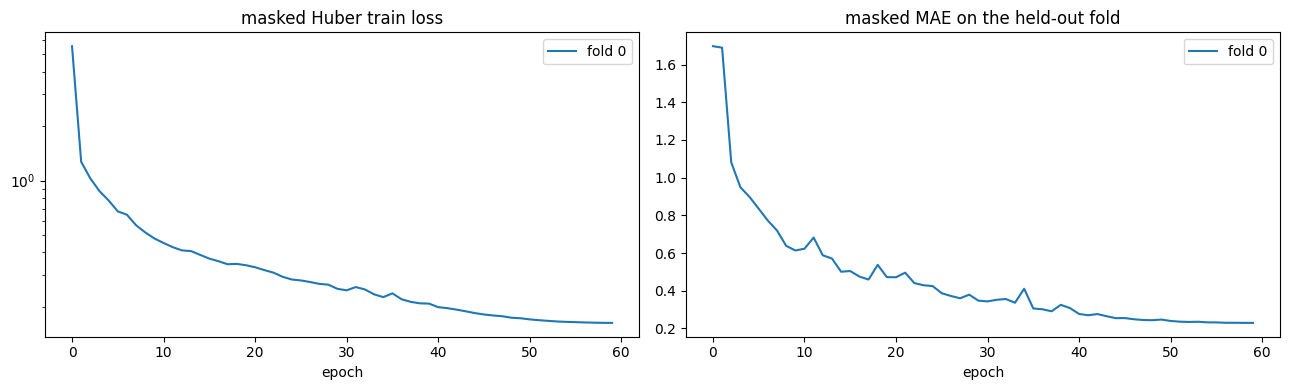

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for fold, history in histories.items():
    ax[0].plot([h[0] for h in history], label=f"fold {fold}")
    ax[1].plot([h[1] for h in history], label=f"fold {fold}")
ax[0].set_title("masked Huber train loss")
ax[0].set_yscale("log")
ax[1].set_title("masked MAE on the held-out fold")
for a in ax:
    a.set_xlabel("epoch")
    a.legend()
plt.tight_layout()
plt.show()

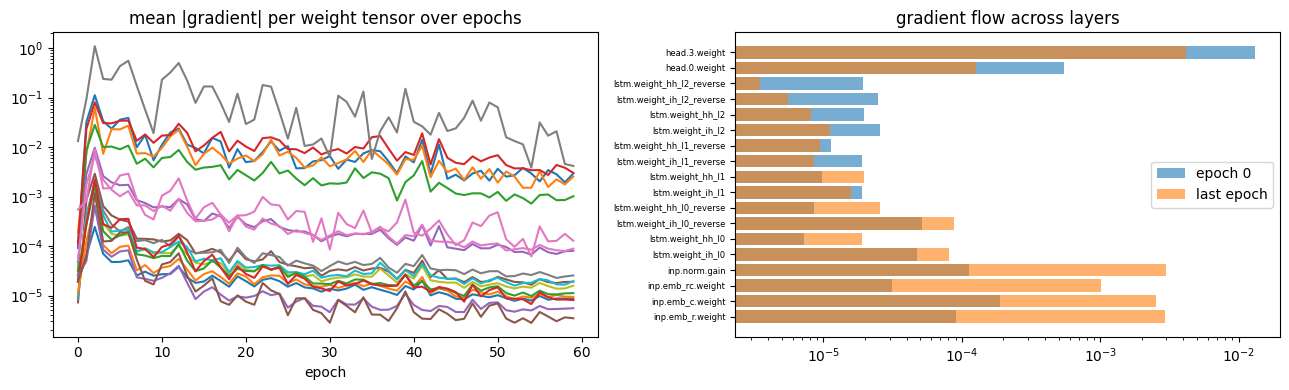

mean |grad| in the last epoch: min 3.47e-06, max 4.15e-03


In [41]:
trace = np.array(grad_trace)
show = [i for i, n in enumerate(param_names) if "bias" not in n]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(trace[:, show])
ax[0].set_yscale("log")
ax[0].set_title("mean |gradient| per weight tensor over epochs")
ax[0].set_xlabel("epoch")
ax[1].barh(range(len(show)), trace[0, show], alpha=0.6, label="epoch 0")
ax[1].barh(range(len(show)), trace[-1, show], alpha=0.6, label="last epoch")
ax[1].set_yticks(range(len(show)))
ax[1].set_yticklabels([param_names[i] for i in show], fontsize=6)
ax[1].set_xscale("log")
ax[1].set_title("gradient flow across layers")
ax[1].legend()
plt.tight_layout()
plt.show()

print(f"mean |grad| in the last epoch: min {trace[-1, show].min():.2e}, max {trace[-1, show].max():.2e}")

**Conclusion:** the val MAE is still going down at the last epoch (0.2319 at 55 -> 0.2293 at 59), so the model is undertrained and more epochs should help. Gradients in the last epoch go from 3.47e-06 to 4.15e-03, about 3 orders of magnitude, and nothing is flat at zero, so the signal does reach the early LSTM layers and the clipping plus LayerNorm are doing their job.

### Comparison

Comparing MLP to LSTM one way and LSTM bidirectional
 
Same features, same loss, same optimizer, same number of epochs, same fold. The only thing that
changes is the architecture, so any difference is down to that and nothing else.

The MLP is applied per timestep and has no memory of its own — whatever it knows about the rest of
the breath comes from the lag and cumsum features built for LightGBM.

In [42]:
class VentilatorMLP(nn.Module):
    def __init__(self, n_cont, hidden=256, dropout=0.1):
        super().__init__()
        self.inp = InputBlock(n_cont)
        self.mlp = nn.Sequential(
            nn.Linear(self.inp.out_dim, hidden),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 128),
            nn.SiLU(),
            nn.Linear(128, 1),
        )

    def forward(self, x, cat):
        return self.mlp(self.inp(x, cat)).squeeze(-1)

In [43]:
ABLATION_EPOCHS = 25
ABLATION_FOLD = 0

ABLATIONS = {
    "MLP per timestep": lambda: VentilatorMLP(len(SEQ_FEATURES)),
    "LSTM one-way": lambda: VentilatorNet(len(SEQ_FEATURES), bidirectional=False),
    "LSTM bidirectional": lambda: VentilatorNet(len(SEQ_FEATURES)),
}

rows = []
for name, build in ABLATIONS.items():
    print(name)
    model, _, _, _, mae = run_fold(ABLATION_FOLD, build=build, epochs=ABLATION_EPOCHS)
    rows.append({"model": name, "params": sum(q.numel() for q in model.parameters()), "fold_MAE": mae})

print(f"\nLightGBM on the same fold: {fold_scores[ABLATION_FOLD]:.4f}, fold-to-fold noise: {fold_std:.5f}")
pd.DataFrame(rows).round(4)

MLP per timestep
epoch 0: loss 7.2287, val MAE 1.8630
epoch 5: loss 0.7847, val MAE 1.0173
epoch 10: loss 0.6489, val MAE 0.9049
epoch 15: loss 0.5794, val MAE 0.8275
epoch 20: loss 0.5469, val MAE 0.7907
epoch 24: loss 0.5372, val MAE 0.7879
LSTM one-way
epoch 0: loss 6.3894, val MAE 1.7643
epoch 5: loss 0.5785, val MAE 0.7175
epoch 10: loss 0.4222, val MAE 0.5840
epoch 15: loss 0.3478, val MAE 0.4571
epoch 20: loss 0.2967, val MAE 0.3905
epoch 24: loss 0.2821, val MAE 0.3774
LSTM bidirectional
epoch 0: loss 5.0115, val MAE 1.6837
epoch 5: loss 0.5839, val MAE 0.7465
epoch 10: loss 0.4002, val MAE 0.5286
epoch 15: loss 0.3042, val MAE 0.3938
epoch 20: loss 0.2516, val MAE 0.3352
epoch 24: loss 0.2350, val MAE 0.3067

LightGBM on the same fold: 0.4684, fold-to-fold noise: 0.00174


,model,params,fold_MAE
0,MLP per timestep,119131,0.7868
1,LSTM one-way,1429083,0.3774
2,LSTM bidirectional,3906139,0.3064


**Conclusion:** MLP 0.7868, one-way LSTM 0.3774, bidirectional 0.3064, all 25 epochs on the same fold. Every step is far bigger than the fold noise 0.00174 so all of them are real.

The MLP is even worse than LightGBM (0.4684) on the exact same features, so a per timestep net is not the point, the memory is. Going one-way -> bidirectional buys another 0.071, which is why I keep bidirectional.

### LightGBM vs LSTM

LightGBM OOF MAE: 0.4684
LSTM OOF MAE: 0.2293


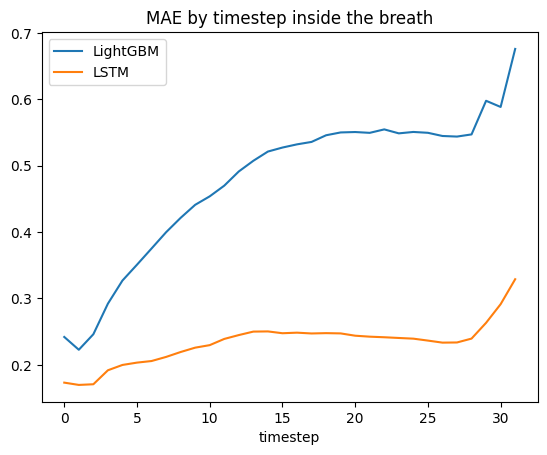

In [44]:
ran = np.isin(train.fold.values, FOLDS_TO_RUN)
scored_rows = ran & (uo == 0)

print(f"LightGBM OOF MAE: {competition_mae(y[ran], oof[ran], uo[ran]):.4f}")
print(f"LSTM OOF MAE: {competition_mae(y[ran], nn_flat[ran], uo[ran]):.4f}")

err_by_t = pd.DataFrame({
    "LightGBM": np.abs(y - oof)[scored_rows],
    "LSTM": np.abs(y - nn_flat)[scored_rows],
}).groupby(train.t.values[scored_rows]).mean()

err_by_t.plot(title="MAE by timestep inside the breath", xlabel="timestep")
plt.show()

In [ ]:
tt = train.t.values[scored_rows]
scale = pd.DataFrame({
    "pressure_std": pd.Series(y[scored_rows]).groupby(tt).std(),
    "LightGBM": pd.Series(np.abs(y - oof)[scored_rows]).groupby(tt).mean(),
    "LSTM": pd.Series(np.abs(y - nn_flat)[scored_rows]).groupby(tt).mean(),
})

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))

scale[["LightGBM", "LSTM"]].plot(ax=ax[0])
ax[0].plot(scale.index, scale.pressure_std, "k--", lw=1, label="pressure std")
ax[0].set_title("absolute MAE by timestep")
ax[0].set_xlabel("timestep")
ax[0].legend(fontsize=8)

scale[["LightGBM", "LSTM"]].div(scale.pressure_std, axis=0).plot(ax=ax[1])
ax[1].set_title("MAE divided by the spread of pressure at that timestep")
ax[1].set_xlabel("timestep")
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(scale.round(3).iloc[::4].to_string())

If the right hand curve is flat, the growing MAE is just the target getting more spread out with time and the model is not actually getting worse. If it still rises, the model really does degrade along the breath.

**Conclusion:** LSTM 0.2293 against LightGBM 0.4684, about twice as good, and the LSTM is lower at every timestep.

But the shape of the two curves is the same, both are small at the start and grow towards the end of the inspiratory phase. Two completely different model families failing in the same place says this is a property of the task and not of the architecture: the target is an integral, so error accumulates along the breath. The LSTM shifts the whole curve down, it does not change its shape.

In [45]:
save_submission(nn_test.ravel(), "/kaggle/working/submission_nn.csv")

## ENSEMBLE

Blend of the tree and the LSTM. The weight is a second-stage model, so it is fitted on the other
folds and applied to the held-out one, never fitted and scored on the same rows. With only one
LSTM fold there are no other folds, so the weight falls back to being fitted on that same fold and
the ensemble score is optimistic. Run all folds for an honest number.

In [46]:
WEIGHTS = np.linspace(0, 1, 101)
row_fold = train.fold.values


def blend_mae(w, rows):
    return np.abs(y[rows] - (w * nn_flat[rows] + (1 - w) * oof[rows])).mean()


ens_oof = np.zeros(len(train), dtype="float32")
chosen = {}

for f in FOLDS_TO_RUN:
    others = [g for g in FOLDS_TO_RUN if g != f] or [f]
    weight_rows = np.isin(row_fold, others) & (uo == 0)
    chosen[f] = float(WEIGHTS[np.argmin([blend_mae(w, weight_rows) for w in WEIGHTS])])
    this = row_fold == f
    ens_oof[this] = chosen[f] * nn_flat[this] + (1 - chosen[f]) * oof[this]

print("weight on the LSTM, per fold:", {k: round(v, 2) for k, v in chosen.items()})
print(f"ensemble OOF MAE: {competition_mae(y[ran], ens_oof[ran], uo[ran]):.4f}")

weight on the LSTM, per fold: {0: 0.96}
ensemble OOF MAE: 0.2282


**Conclusion:** the blend puts 0.96 on the LSTM and gets 0.2282 against 0.2293 for the LSTM alone, so the tree adds almost nothing. Also I only ran one LSTM fold, so the weight was fitted and scored on the same rows and this number is optimistic. I need all 5 folds for an honest ensemble score.

In [47]:
w_final = np.mean(list(chosen.values()))
ens_test = w_final * nn_test.ravel() + (1 - w_final) * test_pred
save_submission(snap_to_grid(ens_test) if use_snapping else ens_test, "/kaggle/working/submission.csv")
print("weight used:", round(w_final, 3))

weight used: 0.96


## IMPROVED LSTM

The first run stopped while the val MAE was still going down (0.2319 at epoch 55 -> 0.2293 at 59)
and it only used one fold. So here I train the same model for longer and on every fold. Nothing
about the architecture changes, only the training budget, so the two runs are comparable.

The first run is kept above on purpose, the two numbers together are the result.

In [ ]:
import time

EPOCHS_V2 = 200
FOLDS_V2 = list(range(N_FOLDS))

nn_oof_v2 = np.zeros_like(y_tr)
nn_test_v2 = np.zeros((len(x_te), N_STEPS), dtype="float32")
histories_v2, scores_v2 = {}, {}

for fold in FOLDS_V2:
    t0 = time.time()
    model, histories_v2[fold], grad_trace_v2, param_names_v2, mae = run_fold(fold, epochs=EPOCHS_V2)

    va_idx = np.where(fold_arr == fold)[0]
    nn_oof_v2[va_idx] = predict(model, x_tr[va_idx], cat_tr[va_idx])
    nn_test_v2 += predict(model, x_te, cat_te) / len(FOLDS_V2)
    scores_v2[fold] = mae

    print(f"fold {fold}: best val MAE {mae:.4f}  ({(time.time() - t0) / 60:.1f} min)", flush=True)
    del model
    torch.cuda.empty_cache()

nn_flat_v2 = nn_oof_v2.ravel()
ran_v2 = np.isin(train.fold.values, FOLDS_V2)

print("\nfold scores:", {k: round(v, 4) for k, v in scores_v2.items()})
print(f"std across folds: {np.std(list(scores_v2.values())):.5f}")
print(f"LSTM v2 OOF MAE: {competition_mae(y[ran_v2], nn_flat_v2[ran_v2], uo[ran_v2]):.4f}")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for fold, hist in histories_v2.items():
    ax[0].plot([h[0] for h in hist], lw=1, label=f"fold {fold}")
    ax[1].plot([h[1] for h in hist], lw=1, label=f"fold {fold}")
ax[0].set_title("v2 train loss")
ax[0].set_yscale("log")
ax[0].set_xlabel("epoch")
ax[0].legend(fontsize=8)
ax[1].set_title("v2 val MAE")
ax[1].set_xlabel("epoch")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

last = {f: h[-1][1] for f, h in histories_v2.items()}
best = {f: min(x[1] for x in h) for f, h in histories_v2.items()}
print("val MAE at the last epoch:", {k: round(v, 4) for k, v in last.items()})
print("best val MAE:            ", {k: round(v, 4) for k, v in best.items()})

**Conclusion:** did it converge this time, or is the curve still going down at epoch 200?

In [ ]:
comparison = pd.DataFrame([
    {"run": "LightGBM", "epochs": None, "folds": N_FOLDS,
     "OOF MAE": lgb_mae},
    {"run": "LSTM v1", "epochs": EPOCHS, "folds": len(FOLDS_TO_RUN),
     "OOF MAE": competition_mae(y[ran], nn_flat[ran], uo[ran])},
    {"run": "LSTM v2, fold 0 only", "epochs": EPOCHS_V2, "folds": 1,
     "OOF MAE": scores_v2[FOLDS_V2[0]]},
    {"run": "LSTM v2, all folds", "epochs": EPOCHS_V2, "folds": len(FOLDS_V2),
     "OOF MAE": competition_mae(y[ran_v2], nn_flat_v2[ran_v2], uo[ran_v2])},
])
comparison.round(4)

**Conclusion:** how much did the longer training buy, and how much did the extra folds buy?

### Ensemble on the improved run

With all five folds the blend weight can finally be fitted on the other folds and applied to the
held out one, so this number is honest, unlike the one from the single fold run above.

In [ ]:
weights = np.linspace(0, 1, 101)
row_fold = train.fold.values


def blend_mae_v2(w, rows):
    return np.abs(y[rows] - (w * nn_flat_v2[rows] + (1 - w) * oof[rows])).mean()


ens_oof_v2 = np.zeros(len(train), dtype="float32")
chosen_v2 = {}

for f in FOLDS_V2:
    others = [g for g in FOLDS_V2 if g != f]
    weight_rows = np.isin(row_fold, others) & (uo == 0)
    chosen_v2[f] = float(weights[np.argmin([blend_mae_v2(w, weight_rows) for w in weights])])
    this = row_fold == f
    ens_oof_v2[this] = chosen_v2[f] * nn_flat_v2[this] + (1 - chosen_v2[f]) * oof[this]

print("weight on the LSTM, per fold:", {k: round(v, 2) for k, v in chosen_v2.items()})
print(f"\nLightGBM alone: {competition_mae(y[ran_v2], oof[ran_v2], uo[ran_v2]):.4f}")
print(f"LSTM v2 alone:  {competition_mae(y[ran_v2], nn_flat_v2[ran_v2], uo[ran_v2]):.4f}")
print(f"ensemble:       {competition_mae(y[ran_v2], ens_oof_v2[ran_v2], uo[ran_v2]):.4f}")

**Conclusion:** is the weight stable across folds, and does the blend still beat the LSTM alone?

In [ ]:
w_v2 = float(np.mean(list(chosen_v2.values())))
ens_test_v2 = w_v2 * nn_test_v2.ravel() + (1 - w_v2) * test_pred

save_submission(nn_test_v2.ravel(), "/kaggle/working/submission_nn_v2.csv")
save_submission(snap_to_grid(ens_test_v2) if use_snapping else ens_test_v2,
                "/kaggle/working/submission.csv")

print("weight used:", round(w_v2, 3))

## RESULTS

| Model | OOF MAE | Public LB | Private LB |
|---|---|---|---|
| constant prediction | 7.6192 | — | — |
| (R, C, t) lookup table | 6.1648 | — | — |
| LightGBM, Huber, 5 folds | 0.4712 | | |
| LightGBM + grid snapping | 0.4707 | — | — |
| LSTM v1, 60 epochs, 1 fold | 0.2293 | | |
| LSTM v2, 200 epochs, 5 folds | | | |
| ensemble v1 (optimistic, 1 fold) | 0.2282 | — | — |
| ensemble v2 | | | |

Architecture ablation, fold 0, 25 epochs each: MLP 0.7868, one-way LSTM 0.3774, bidirectional LSTM 0.3064.
